# Validating Impact Functions

-> Goal: Be in Range of actual recorded losses

## Import Hazards

In [1]:
## So that if you change sth in a src script you don't have to restart the kernel
%load_ext autoreload
%autoreload 2

In [50]:
## Imports
## Allowing for Imports from src folder
import sys
sys.path.append("..") # Adds the project root to the path

In [51]:
## Getting hazard Dict
from src.data_hazard import get_haz_dict

## TODO: Enable Floods!
haz_dict = get_haz_dict()

haz_dict.keys()

dict_keys(['TC', 'TP', 'HL', 'FL'])

In [52]:
from src.data_exposure import get_exposure

hazard_types = list(haz_dict.keys())

exposure_poly = get_exposure(hazard_types=hazard_types)

exposure_poly_gdf = exposure_poly.gdf

exposure_poly_gdf.head()

,DDEP_C_COD,DDEP_L_LIB,DREG_L_LIB,value,area,insurance,impf_TC,impf_TP,impf_HL,impf_FL,geometry
0,01,Ain,Auvergne-Rhône-Alpes,0.199,5762.4,0.30,1,1,1,1,"POLYGON ((6.16845 46.36746, 6.16668 46.37074, ..."
1,02,Aisne,Hauts-de-France,0.532,7361.7,0.32,1,1,1,1,"POLYGON ((4.25573 49.90398, 4.23694 49.90378, ..."
2,03,Allier,Auvergne-Rhône-Alpes,0.170,7340.1,0.30,1,1,1,1,"POLYGON ((4.00456 46.32748, 3.99436 46.32765, ..."
3,04,Alpes-de-Haute-Provence,Provence-Alpes-Côte d'Azur,0.025,6925.2,0.18,1,1,1,1,"POLYGON ((6.96709 44.62287, 6.9539 44.63783, 6..."
4,05,Hautes-Alpes,Provence-Alpes-Côte d'Azur,0.017,5548.7,0.18,1,1,1,1,"POLYGON ((7.07587 44.68512, 7.07424 44.69209, ..."


In [53]:
import climada.util.lines_polys_handler as u_lp

# Don't make Resolution too Small!
exposure_pnt = u_lp.exp_geom_to_pnt(
    exposure_poly,
    res=1000,
    to_meters=True,
    disagg_met=u_lp.DisaggMethod.FIX,
    disagg_val=None,
)

exposure_pnt_gdf = exposure_pnt.gdf

## General Workflow

In [54]:
from src.helpers import agg_to_departement

def comp_rel_damage(exposure_pnt_gdf):
    
    impact_poly_gdf = agg_to_departement(
        exposure_pnt_gdf,
        value_cols=["value", "eai"]
    )
    
    damaged_area = (impact_poly_gdf["eai"] * impact_poly_gdf["value"] * impact_poly_gdf["area"]).sum()
    total_area = (impact_poly_gdf["area"]).sum()
    
    rel_damage = damaged_area / total_area
    
    return rel_damage
    

### Heat

<Axes: title={'center': 'TC 1: Max Temp Impact Function (Paper)'}, xlabel='Intensity (m/s)', ylabel='Impact (%)'>

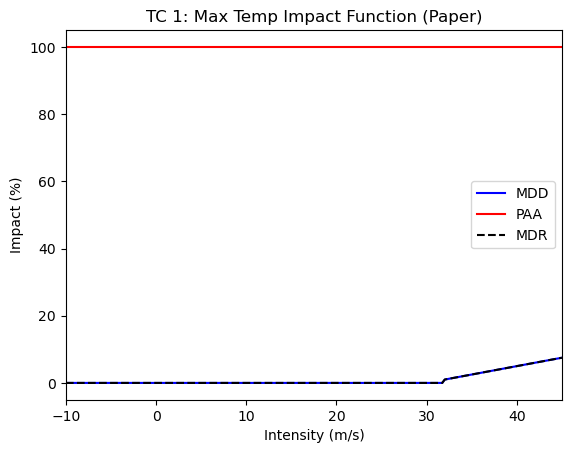

In [24]:
haz_dict["TC"]["impf_set"].plot()

In [7]:
from src.helpers import comp_impact

hazard = "TC"

haz_dict_sel = {}
haz_dict_sel[hazard] = haz_dict[hazard]

exposure_pnt_gdf["eai"] = comp_impact(
    haz_dict=haz_dict_sel,
    exposure_pnt_gdf=exposure_pnt_gdf
)

Computing TC
0.0585669304487189


In [8]:
comp_rel_damage(exposure_pnt_gdf)

0.012489021853640448

### Precipitation

<Axes: title={'center': 'TP 1: Total Precipitation Impact Function (ChatGPT)'}, xlabel='Intensity (mm)', ylabel='Impact (%)'>

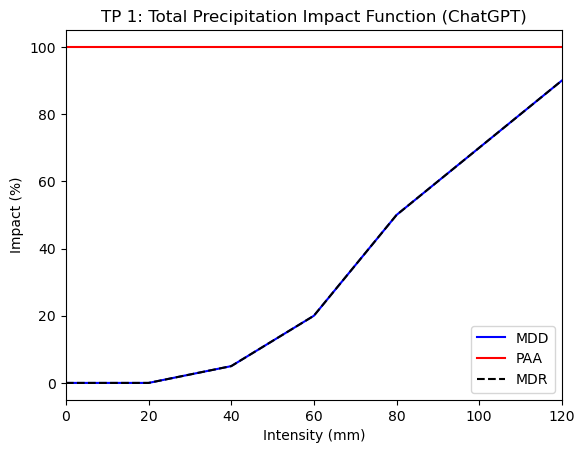

In [9]:
haz_dict["TP"]["impf_set"].plot()

<Axes: title={'center': 'TP 1: Total Precipitation Impact Function (ChatGPT)'}, xlabel='Intensity (mm)', ylabel='Impact (%)'>

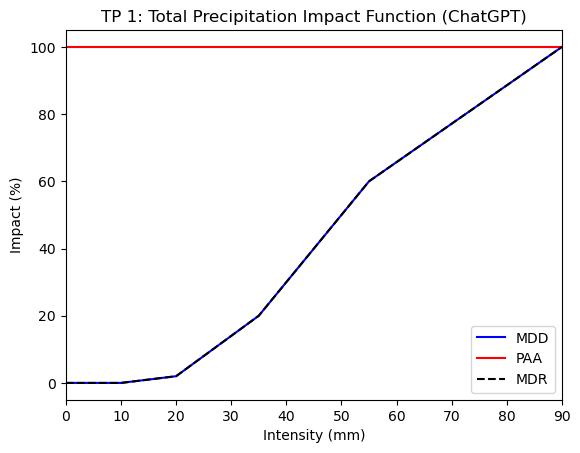

In [28]:
import numpy as np
from climada.entity import ImpactFunc
from climada.entity.impact_funcs import ImpactFuncSet
## Experiment with Impactfunction:

## Define Respective Impact Function
precipitation = np.array([0, 10, 20, 35, 55, 90])
damage        = np.array([0, 0, 0.02, 0.2, 0.6, 1.0])
impf_TP = ImpactFunc(
    id=1,
    name = "Total Precipitation Impact Function (ChatGPT)",
    intensity_unit="mm",
    haz_type="TP",
    intensity=precipitation,
    mdd=damage,
    paa = np.ones_like(precipitation)
)

impf_set_sel = ImpactFuncSet([impf_TP])

impf_set_sel.plot()

In [29]:
from src.helpers import comp_impact

hazard = "TP"

haz_dict_sel = {}
haz_dict_sel[hazard] = haz_dict[hazard]

haz_dict_sel[hazard]["impf_set"] = impf_set_sel

exposure_pnt_gdf["eai"] = comp_impact(
    haz_dict=haz_dict_sel,
    exposure_pnt_gdf=exposure_pnt_gdf
)

Computing TP
np.mean(impact_pnt.eai_exp) = 0.0003482253140847016


In [30]:
comp_rel_damage(exposure_pnt_gdf)

3.1602688214584124e-05

<GeoAxes: title={'center': 'TP max intensity at each point'}>

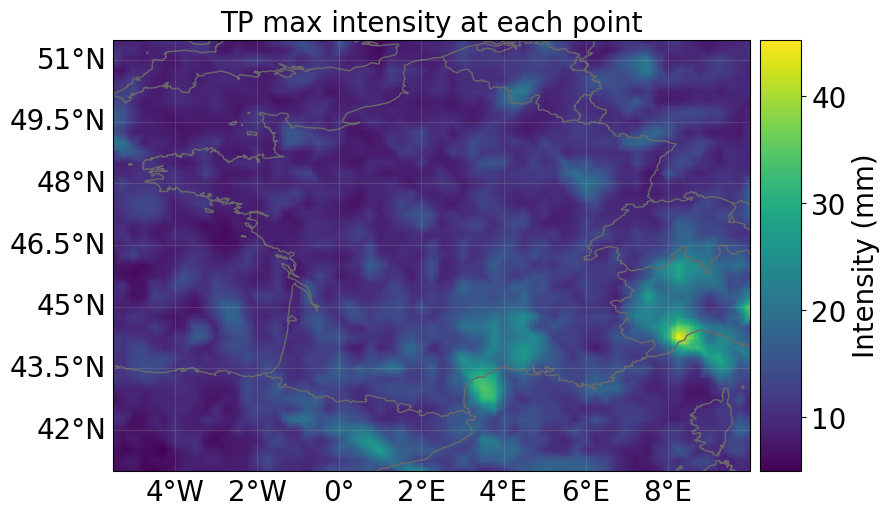

In [31]:
haz_dict["TP"]["hazard"].plot_intensity(event=0)

### Hail

<Axes: title={'center': 'HL 1: Hail Impact Function (Papers)'}, xlabel='Intensity (mm)', ylabel='Impact (%)'>

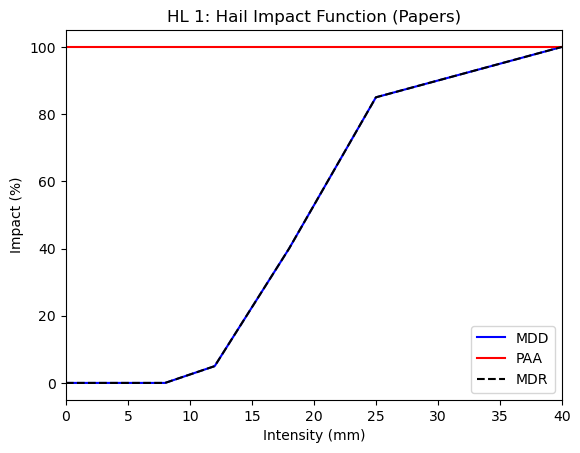

In [41]:
haz_dict["HL"]["impf_set"].plot()

<Axes: title={'center': 'HL 1: Hail Impact Function (Papers)'}, xlabel='Intensity (mm)', ylabel='Impact (%)'>

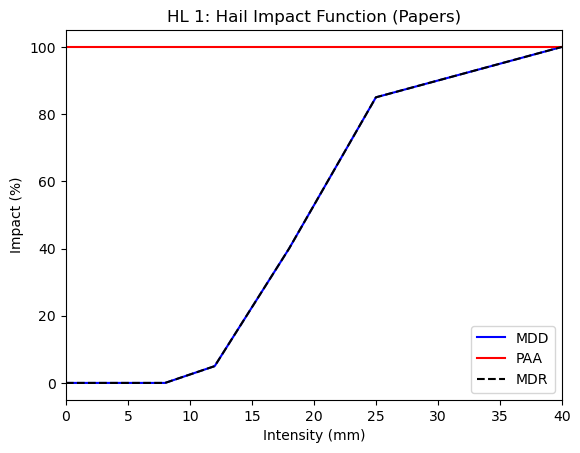

In [45]:
## Define Respective Impact Function
diameter = np.array([0, 8, 12, 18, 25, 40])

damage   = np.array([0.0, 0.0, 0.05, 0.4, 0.85, 1.0])

## Define Respective Impact Function
# diameter = np.array([0, 6, 10, 20, 30, 50])

# Mean Damage Degree (0–1)
# damage = np.array([0.0, 0.05, 0.15, 0.35, 0.60, 0.90])

impf_HL = ImpactFunc(
    id=1,
    name = "Hail Impact Function (Papers)",
    intensity_unit="mm",
    haz_type="HL",
    intensity=diameter,
    mdd=damage,
    paa = np.ones_like(diameter)
)

impf_set_sel = ImpactFuncSet([impf_HL])

impf_set_sel.plot()

In [46]:
from src.helpers import comp_impact

hazard = "HL"

haz_dict_sel = {}
haz_dict_sel[hazard] = haz_dict[hazard]

haz_dict_sel[hazard]["impf_set"] = impf_set_sel

exposure_pnt_gdf["eai"] = comp_impact(
    haz_dict=haz_dict_sel,
    exposure_pnt_gdf=exposure_pnt_gdf
)

Computing HL
2026-05-08 09:15:03,819 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.000237 degree for 548477 coordinates.
np.mean(impact_pnt.eai_exp) = 0.00011237448874200075


In [47]:
comp_rel_damage(exposure_pnt_gdf)

2.414890264222052e-05

### River Floods

<Axes: title={'center': 'FL 1: Flood Impact Function (Climada API)'}, xlabel='Intensity (mm)', ylabel='Impact (%)'>

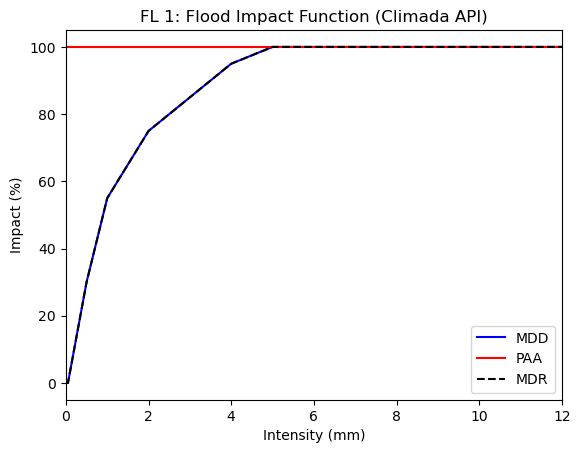

In [17]:
haz_dict["FL"]["impf_set"].plot()

In [18]:
from src.helpers import comp_impact

hazard = "FL"

haz_dict_sel = {}
haz_dict_sel[hazard] = haz_dict[hazard]

exposure_pnt_gdf["eai"] = comp_impact(
    haz_dict=haz_dict_sel,
    exposure_pnt_gdf=exposure_pnt_gdf
)

Computing FL
2026-05-08 08:56:27,287 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.004492 degree for 14285 coordinates.
np.mean(impact_pnt.eai_exp) = 5.118030317158632e-05


In [19]:
comp_rel_damage(exposure_pnt_gdf)

6.198586430993904e-06

## Total

In [55]:
from src.helpers import comp_impact

exposure_pnt_gdf["eai"] = comp_impact(
    haz_dict=haz_dict,
    exposure_pnt_gdf=exposure_pnt_gdf
)

Computing TC
np.mean(impact_pnt.eai_exp) = 0.0585669304487189
Computing TP
np.mean(impact_pnt.eai_exp) = 0.0003482253140847016
Computing HL
2026-05-08 09:23:38,743 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.000237 degree for 548477 coordinates.
np.mean(impact_pnt.eai_exp) = 0.0001654377992320296
Computing FL
2026-05-08 09:30:10,609 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.004492 degree for 14285 coordinates.
np.mean(impact_pnt.eai_exp) = 5.118030317158632e-05


In [56]:
comp_rel_damage(exposure_pnt_gdf)

0.012553818282852217